In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Show first 5 rows
print("✅ Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
df.head()

✅ Dataset loaded successfully!
Total Rows: 7043
Total Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check basic information about the dataset
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

print("\n")
print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


MISSING VALUES CHECK
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


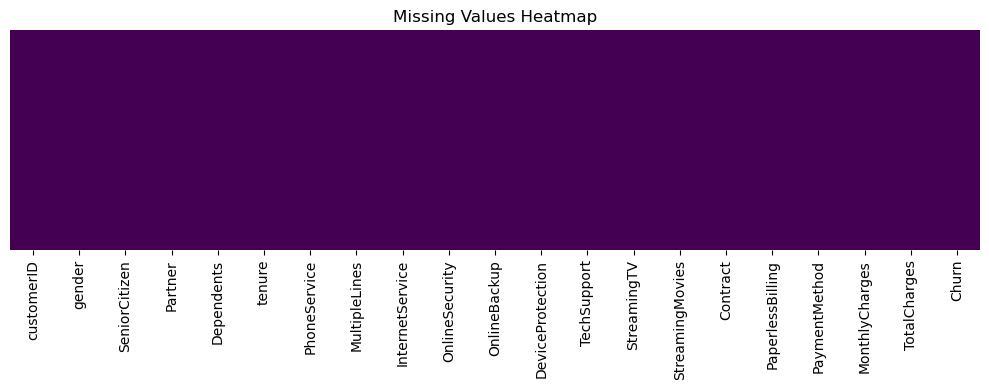


✅ Missing values check complete!


In [4]:
# Check missing values in each column
print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

print(missing_df[missing_df['Missing Values'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

print("\n✅ Missing values check complete!")

CHURN DISTRIBUTION
Customers Stayed  : 5174  (73.5%)
Customers Churned : 1869 (26.5%)


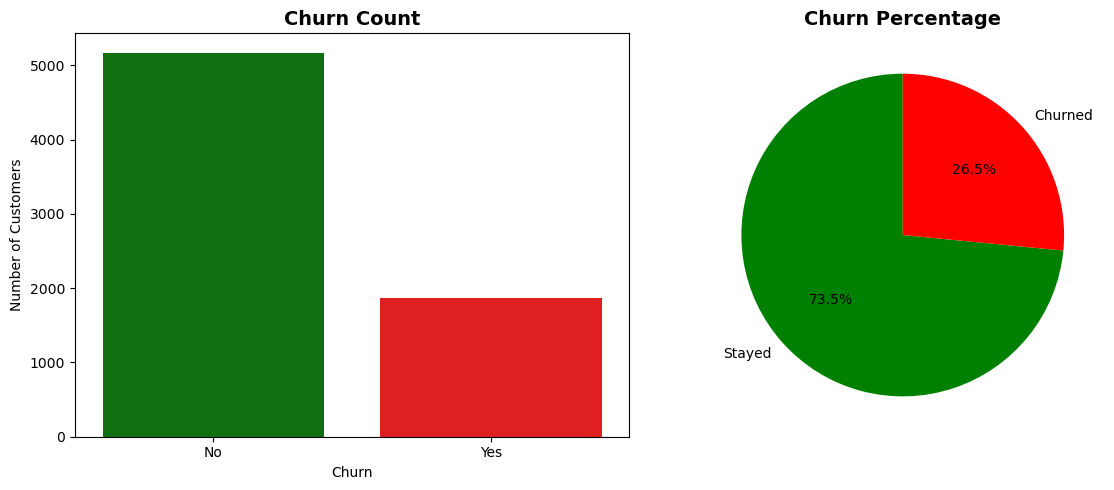


✅ Churn distribution complete!


In [9]:
# Check how many customers churned vs stayed
print("=" * 50)
print("CHURN DISTRIBUTION")
print("=" * 50)

# Count values
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print(f"Customers Stayed  : {churn_counts['No']}  ({churn_percent['No']:.1f}%)")
print(f"Customers Churned : {churn_counts['Yes']} ({churn_percent['Yes']:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.countplot(x='Churn', data=df, palette=['green', 'red'], ax=axes[0])
axes[0].set_title("Churn Count", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Number of Customers")

# Pie chart
axes[1].pie(churn_counts, labels=['Stayed', 'Churned'],
            colors=['green', 'red'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Churn Percentage", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Churn distribution complete!")

FEATURE ANALYSIS


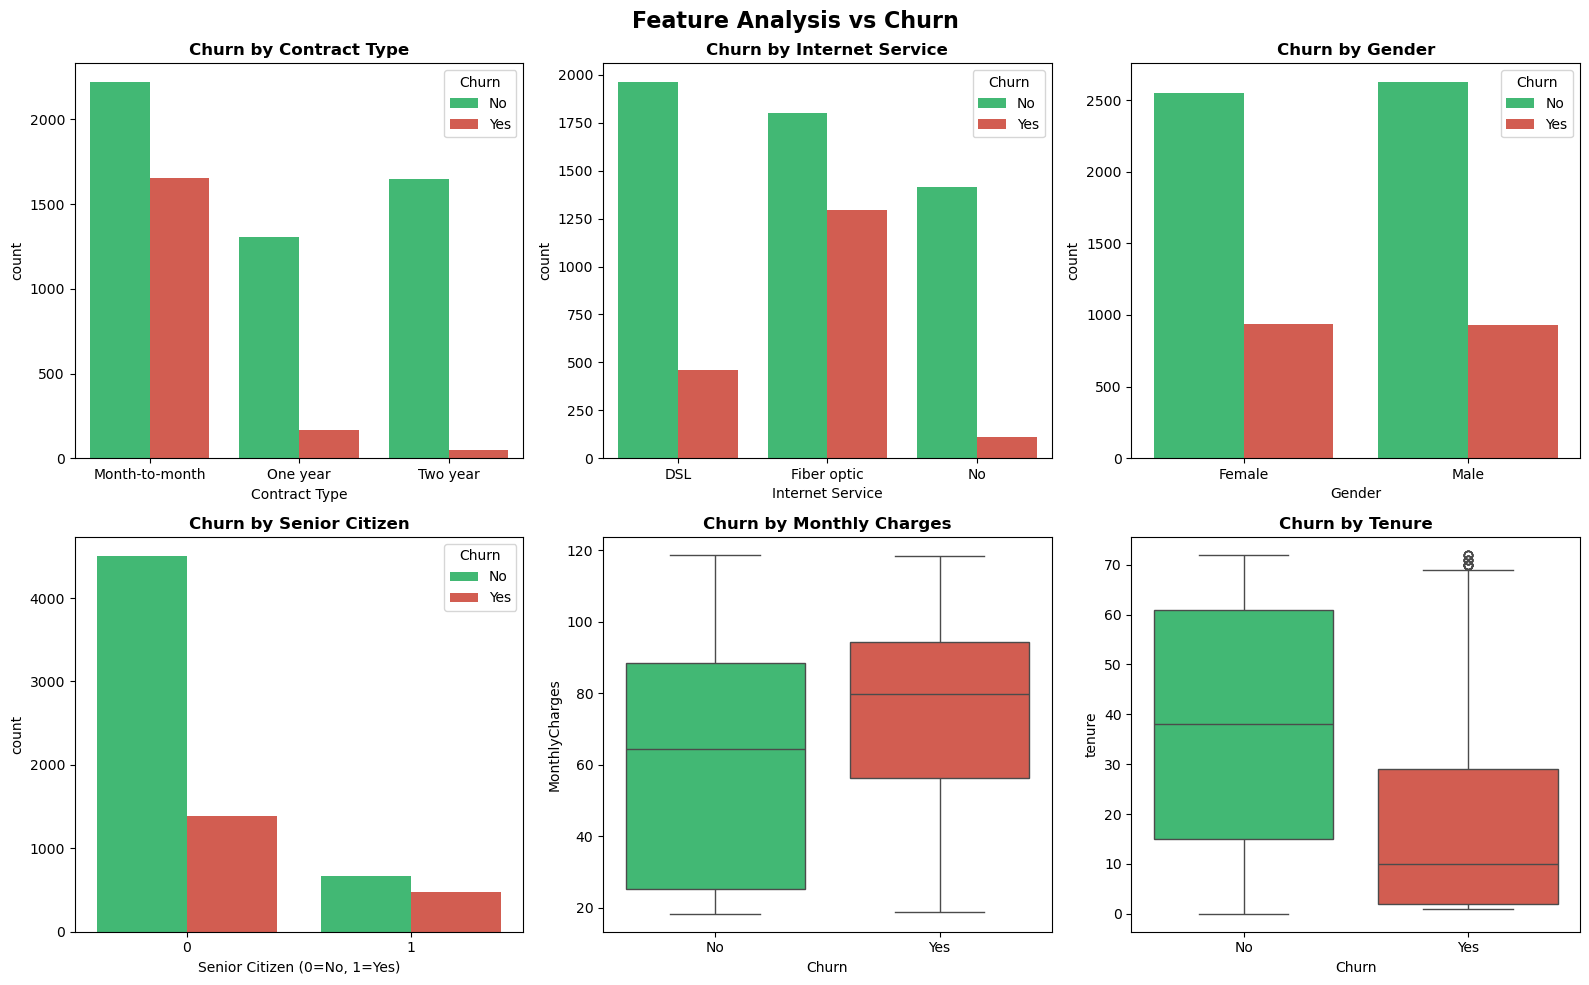


✅ Feature analysis complete!


In [10]:
# Analyze how different features affect churn
print("=" * 50)
print("FEATURE ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[0, 0])
axes[0, 0].set_title("Churn by Contract Type", fontweight='bold')
axes[0, 0].set_xlabel("Contract Type")

# 2. Churn by Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1])
axes[0, 1].set_title("Churn by Internet Service", fontweight='bold')
axes[0, 1].set_xlabel("Internet Service")

# 3. Churn by Gender
sns.countplot(x='gender', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[0, 2])
axes[0, 2].set_title("Churn by Gender", fontweight='bold')
axes[0, 2].set_xlabel("Gender")

# 4. Churn by Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title("Churn by Senior Citizen", fontweight='bold')
axes[1, 0].set_xlabel("Senior Citizen (0=No, 1=Yes)")

# 5. Churn by Monthly Charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1, 1])
axes[1, 1].set_title("Churn by Monthly Charges", fontweight='bold')
axes[1, 1].set_xlabel("Churn")

# 6. Churn by Tenure
sns.boxplot(x='Churn', y='tenure', data=df,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1, 2])
axes[1, 2].set_title("Churn by Tenure", fontweight='bold')
axes[1, 2].set_xlabel("Churn")

plt.suptitle("Feature Analysis vs Churn", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Feature analysis complete!")

CORRELATION ANALYSIS


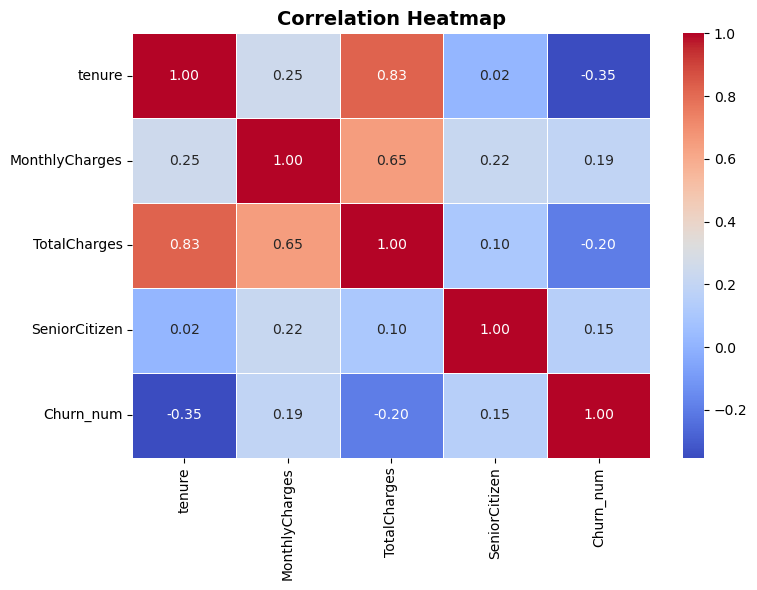


✅ Correlation analysis complete!


In [11]:
# Check correlation between numeric features
print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

# Convert TotalCharges to numeric (it's stored as text in this dataset)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill any NaN created by conversion
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to numeric for correlation
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select numeric columns only
numeric_cols = df[['tenure', 'MonthlyCharges', 'TotalCharges',
                   'SeniorCitizen', 'Churn_num']]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Correlation analysis complete!")

In [12]:
# Feature Engineering — Creating new smart features
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# 1. Tenure Group — categorize customers by how long they've been with us
def tenure_group(tenure):
    if tenure <= 12:
        return 'New'        # 0-12 months
    elif tenure <= 24:
        return 'Developing'  # 13-24 months
    elif tenure <= 48:
        return 'Mature'      # 25-48 months
    else:
        return 'Loyal'       # 49+ months

df['tenure_group'] = df['tenure'].apply(tenure_group)

# 2. Avg Monthly Spend — how much customer pays per month on average
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Has Premium Services — does customer use any premium service?
df['has_premium_services'] = (
    (df['OnlineSecurity'] == 'Yes') |
    (df['OnlineBackup'] == 'Yes') |
    (df['DeviceProtection'] == 'Yes') |
    (df['TechSupport'] == 'Yes')
).astype(int)

# 4. Is High Value Customer — high tenure + high charges
df['is_high_value'] = (
    (df['tenure'] > 24) &
    (df['MonthlyCharges'] > 50)
).astype(int)

# 5. Number of services customer uses
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1
)

# Show new features
print("New features created:")
print(df[['tenure', 'tenure_group', 'avg_monthly_spend',
          'has_premium_services', 'is_high_value',
          'num_services', 'Churn']].head(10))

print(f"\n✅ Feature engineering complete!")
print(f"Total features now: {df.shape[1]}")

FEATURE ENGINEERING
New features created:
   tenure tenure_group  avg_monthly_spend  has_premium_services  \
0       1          New          14.925000                     1   
1      34       Mature          53.985714                     1   
2       2          New          36.050000                     1   
3      45       Mature          40.016304                     1   
4       2          New          50.550000                     0   
5       8          New          91.166667                     1   
6      22   Developing          84.756522                     1   
7      10          New          27.445455                     1   
8      28       Mature         105.036207                     1   
9      62        Loyal          55.364286                     1   

   is_high_value  num_services Churn  
0              0             1    No  
1              1             3    No  
2              0             3   Yes  
3              0             3    No  
4              0         

In [13]:
# Save the cleaned and engineered dataset
print("=" * 50)
print("SAVING CLEAN DATASET")
print("=" * 50)

# Save to data folder
df.to_csv('../data/churn_clean.csv', index=False)

print("✅ Clean dataset saved as 'churn_clean.csv'")
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print("\nColumns in clean dataset:")
for col in df.columns:
    print(f"  → {col}")


SAVING CLEAN DATASET
✅ Clean dataset saved as 'churn_clean.csv'
Total Rows    : 7043
Total Columns : 27

Columns in clean dataset:
  → customerID
  → gender
  → SeniorCitizen
  → Partner
  → Dependents
  → tenure
  → PhoneService
  → MultipleLines
  → InternetService
  → OnlineSecurity
  → OnlineBackup
  → DeviceProtection
  → TechSupport
  → StreamingTV
  → StreamingMovies
  → Contract
  → PaperlessBilling
  → PaymentMethod
  → MonthlyCharges
  → TotalCharges
  → Churn
  → Churn_num
  → tenure_group
  → avg_monthly_spend
  → has_premium_services
  → is_high_value
  → num_services
